In [107]:
import numpy as np
from scipy.optimize import bisect, brentq, newton, root_scalar
import matplotlib.pyplot as plt
import cmath
from scipy.optimize import newton_krylov
from numpy.polynomial import Polynomial

# Zadanie 1.


## Metoda bisekcji


Caly czas rozdzielamy przedziały na pół

In [132]:
def bisection_method(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) >= 0:
        raise ValueError("Funkcja musi mieć przeciwne znaki na końcach przedziału (a, b).")

    iteration = 0
    while (b - a) / 2 > tol and iteration < max_iter:
        m = (a + b) / 2
        f_m = f(m)

        if f_m == 0:
            return m, iteration  # znaleziono dokładny pierwiastek
        elif f(a) * f_m < 0:
            b = m
        else:
            a = m

        iteration += 1

    return (a + b) / 2, iteration

## Metoda Bretna

dzielimy wyjściowy przedział (a, b) izolacji pierwiastka na połowę
• określamy, w którym z przedziałów (a,c)
i (c, b) leży
poszukiwany pierwiastek
• przez punkty (a, f(a)), (c, f(c)) i (b, f(b)) prowadzimy parabolę i
szukamy punktu przecięcia z osią X

In [4]:
def brent_method(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) >= 0:
        raise ValueError("Funkcja musi mieć przeciwne znaki na końcach przedziału (a, b).")

    # Inicjalizacja punktów a, b, c
    fa, fb = f(a), f(b)
    c = a
    fc = fa

    for iteration in range(max_iter):
        if fa != fc and fb != fc:
            # Interpolacja przez parabolę
            s = (a * fb * fc / ((fa - fb) * (fa - fc)) +
                 b * fa * fc / ((fb - fa) * (fb - fc)) +
                 c * fa * fb / ((fc - fa) * (fc - fb)))
        else:
            # Bisekcja
            s = (a + b) / 2

        # Sprawdzenie, czy s leży w przedziale (a, b)
        if not (min(a, b) < s < max(a, b)):
            s = (a + b) / 2

        fs = f(s)
        # Aktualizacja przedziału
        if fs == 0:
            return s, iteration  # znaleziono dokładny pierwiastek

        if fa * fs < 0:
            b, fb = s, fs
        else:
            a, fa = s, fs

        # Ustawienie c na poprzednią wartość b
        c, fc = b, fb

        # Sprawdzenie tolerancji
        if abs(b - a) < tol:
            return s, iteration

    return s, iteration


## Metoda siecznych
Rysujemy cieciwe przez A i B i za pomocą tego wozru aproksymacja

In [5]:
def secant_method(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) >= 0:
        raise ValueError("Funkcja musi mieć przeciwne znaki na końcach przedziału (a, b).")

    x0, x1 = a, b
    f_x0, f_x1 = f(x0), f(x1)

    for iteration in range(max_iter):
        if f_x1 - f_x0 == 0:
            raise ValueError("Dzielenie przez zero w metodzie siecznych.")

        # Obliczanie kolejnego przybliżenia pierwiastka
        x2 = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)

        # Sprawdzenie tolerancji
        if abs(x2 - x1) < tol:
            return x2, iteration

        # Aktualizacja punktów
        x0, x1 = x1, x2
        f_x0, f_x1 = f_x1, f(x2)

    return x2, iteration

## Metoda Newtona (stycznych)
od końca przedziału, w którym funkcja f(x) ma ten sam znak co jej
druga pochodna, prowadzimy styczną do wykresu funkcji
• punkt x1 przecięcia stycznej z osią X pierwszym przybliżeniem
pierwiastka
• z punktu (x1
, f(x1)) prowadzimy następną styczną i określamy kolejne
przybliżenie
• powtarzamy aż do uzyskania żądanej dokładności


In [127]:
def newton_method(f, f_prime, x0, tol=1e-6, max_iter=100):
    x = x0
    for iteration in range(max_iter):
        f_x = f(x)
        f_prime_x = f_prime(x)

        if f_prime_x == 0:
            raise ValueError("Pochodna wynosi zero, metoda Newtona nie może być kontynuowana.")

        # Obliczanie kolejnego przybliżenia pierwiastka
        x_next = x - f_x / f_prime_x

        # Sprawdzenie tolerancji
        if abs(x_next - x) < tol:
            return x_next, iteration

        x = x_next

    return x, iteration

### Rozwiązanie równania tymi sposobami i porównanie z wbudowanymi funkcjami 

In [139]:

# Definicja funkcji f(x) oraz jej pochodnej
def f(x):
    return np.tan(np.pi - x) - x

def f_prime(x):
    try:
        return -1 - 1 / (np.cos(np.pi - x) ** 2)  # dla metody Newtona
    except ZeroDivisionError:
        return np.inf

# Zakres poszukiwań
a, b = 1.96, 2.74  # Dopasowanie przedziału dla metod wymagających przeciwnych znaków wartości funkcji
x0 = 2  # Początkowe przybliżenie dla metody Newtona

# Własne implementacje metod
try:
    x_bisection, iter_bisection = bisection_method(f, a, b)
    mul_add_bisection = iter_bisection * 2  # Dla bisekcji: 2 operacje na iterację (średnia i warunek znaku)
    print(f"Metoda bisekcji: x = {x_bisection:.6f}, f(x) = {f(x_bisection):.2e}, liczba iteracji = {iter_bisection}, liczba mnożeń/dodawań = {mul_add_bisection}")
except Exception as e:
    print(f"Błąd w metodzie bisekcji: {e}")

try:
    x_brent, iter_brent = brent_method(f, a, b)
    mul_add_brent = iter_brent * 5  # Przybliżona liczba operacji dla metody Brenta
    print(f"Metoda Brenta: x = {x_brent:.6f}, f(x) = {f(x_brent):.2e}, liczba iteracji = {iter_brent}, liczba mnożeń/dodawań = {mul_add_brent}")
except Exception as e:
    print(f"Błąd w metodzie Brenta: {e}")

try:
    x_secant, iter_secant = secant_method(f, a, b)
    mul_add_secant = iter_secant * 3  # Dla metody siecznych: 3 operacje na iterację
    print(f"Metoda siecznych: x = {x_secant:.6f}, f(x) = {f(x_secant):.2e}, liczba iteracji = {iter_secant}, liczba mnożeń/dodawań = {mul_add_secant}")
except Exception as e:
    print(f"Błąd w metodzie siecznych: {e}")

try:
    x_newton, iter_newton = newton_method(f, f_prime, x0)
    mul_add_newton = iter_newton * 4  # Przybliżona liczba operacji dla metody Newtona
    print(f"Metoda Newtona: x = {x_newton:.6f}, f(x) = {f(x_newton):.2e}, liczba iteracji = {iter_newton}, liczba mnożeń/dodawań = {mul_add_newton}")
except Exception as e:
    print(f"Błąd w metodzie Newtona: {e}")


Metoda bisekcji: x = 2.028758, f(x) = 4.60e-07, liczba iteracji = 19, liczba mnożeń/dodawań = 38
Metoda Brenta: x = 2.028758, f(x) = 4.60e-07, liczba iteracji = 19, liczba mnożeń/dodawań = 95
Metoda siecznych: x = 2.028758, f(x) = -2.82e-13, liczba iteracji = 6, liczba mnożeń/dodawań = 18
Metoda Newtona: x = 2.028758, f(x) = 0.00e+00, liczba iteracji = 3, liczba mnożeń/dodawań = 12


### Użycie wbudowanych funkcji scipy

In [140]:
# Wbudowane funkcje z scipy
x_bisect_scipy = bisect(f, a, b, xtol=1e-6, maxiter=100)
x_brent_scipy = brentq(f, a, b, xtol=1e-6, maxiter=100)
x_secant_scipy = root_scalar(f, method='secant', x0=a, x1=b, xtol=1e-6, maxiter=100).root
x_newton_scipy = newton(f, x0, fprime=f_prime, tol=1e-6, maxiter=100)

# Zapisywanie wyników
print(f"Metoda bisekcji (scipy): x = {x_bisect_scipy:.6f}")
print(f"Metoda Brenta (scipy): x = {x_brent_scipy:.6f}")
print(f"Metoda siecznych (scipy): x = {x_secant_scipy:.6f}")
print(f"Metoda Newtona (scipy): x = {x_newton_scipy:.6f}")

Metoda bisekcji (scipy): x = 2.028758
Metoda Brenta (scipy): x = 2.028758
Metoda siecznych (scipy): x = 2.028758
Metoda Newtona (scipy): x = 2.028758


# Zadanie 2

Metoda Newtona: x = 10.995608, f(x) = 1.72e-08
Metoda Newtona (scipy): x = 10.995608


<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
C:\Users\oliwi\AppData\Local\Temp\ipykernel_11868\479387469.py:17: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Wykres funkcji $f(x) = \cosh(x) \cos(x) - 1$ w przedziale $4 \leq x \leq 8$')


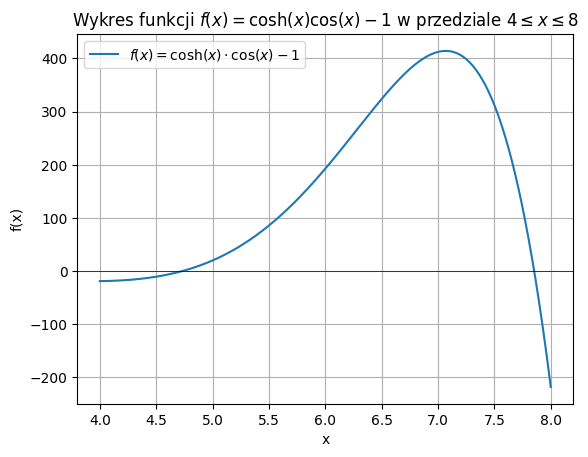

In [143]:
# Definicja funkcji f(x) oraz jej pochodnej
def f(x):
    return np.cosh(x) * np.cos(x) - 1

def f_prime(x):
    return np.sinh(x) * np.cos(x) - np.cosh(x) * np.sin(x)

# Zakres do wykresu
x = np.linspace(4, 8, 1000)
y = f(x)

# Wykres funkcji f(x)
plt.plot(x, y, label=r'$f(x) = \cosh(x) \cdot \cos(x) - 1$')
plt.axhline(0, color='black', lw=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Wykres funkcji $f(x) = \cosh(x) \cos(x) - 1$ w przedziale $4 \leq x \leq 8$')
plt.legend()
plt.grid(True)

# Przykład działania metody Newtona z punktem startowym x0 = 4
x0 = 4
try:
    x_newton, iter_newton = newton_method(f, f_prime, x0)
    print(f"Metoda Newtona: x = {x_newton:.6f}, f(x) = {f(x_newton):.2e}")
except ValueError as e:
    print(f"Błąd w metodzie Newtona: {e}")


x_newton_scipy = newton(f, x0, fprime=f_prime, tol=1e-6, maxiter=100)
print(f"Metoda Newtona (scipy): x = {x_newton_scipy:.6f}")



<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\oliwi\AppData\Local\Temp\ipykernel_11868\1243948341.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Wykres drugiej pochodnej $f''(x)$ w przedziale $4 \leq x \leq 8$')


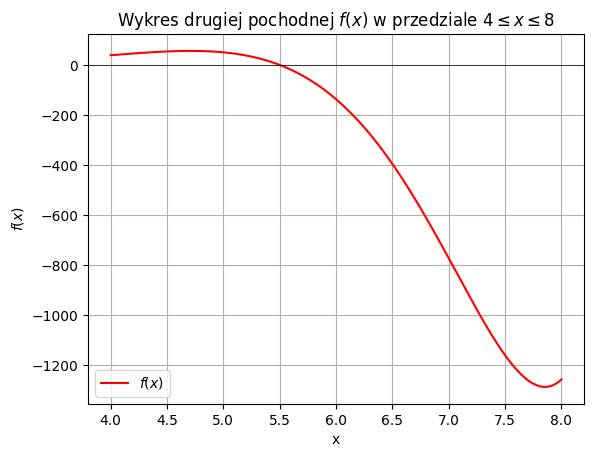

In [35]:
def f_double_prime(x):
    return np.cosh(x) * np.sin(x) - 2 * np.sinh(x) * np.sin(x) - np.cosh(x) * np.cos(x)
# Wykres drugiej pochodnej f''(x)
y_double_prime = f_double_prime(x)
plt.plot(x, y_double_prime, label=r'$f''(x)$', color='red')
plt.axhline(0, color='black', lw=0.5)
plt.xlabel('x')
plt.ylabel(r'$f''(x)$')
plt.title('Wykres drugiej pochodnej $f''(x)$ w przedziale $4 \leq x \leq 8$')
plt.legend()
plt.grid(True)

# Zadanie 3

In [ ]:

# Dane
u = 2510  # m/s, prędkość spalin względem rakiety
M0 = 2.8 * 10**6  # kg, masa początkowa rakiety
m_dot = 13.3 * 10**3  # kg/s, szybkość zużycia paliwa
g = 9.81  # m/s^2, przyspieszenie ziemskie
v_sound = 335  # m/s, prędkość dźwięku

# Funkcja do wyznaczenia prędkości
def velocity(t):
    if M0 - m_dot * t <= 0:
        return np.nan  
    return u * np.log(M0 / (M0 - m_dot * t)) - g * t

# Funkcja, której szukamy miejsca zerowego
def velocity_difference(t):
    if np.isnan(velocity(t)):
        return np.inf  
    return velocity(t) - v_sound

# Szukanie rozwiązania równania za pomocą metody bisekcji
a =1   # początek przedziału
b = 100 # koniec przedziału
t_solution = bisection_method(velocity_difference, a, b)
#print(velocity(100))
# Wynik
print(f"Czas potrzebny do osiągnięcia prędkości dźwięku: {t_solution:.2f} s")


636.3361111401882
Czas potrzebny do osiągnięcia prędkości dźwięku: 70.88 s


In [68]:
t_solutio = brentq(velocity_difference, a, b)

# Wynik
print(f"Czas potrzebny do osiągnięcia prędkości dźwięku: {t_solutio:.2f} s")

Czas potrzebny do osiągnięcia prędkości dźwięku: 70.88 s


# Zadanie 4

In [96]:
# Dane
R = 8.31441  # J/K, stała gazowa
T0 = 4.44418  # K, temperatura odniesienia
G_target = -105  # J, energia swobodna Gibbsa, której szukamy

# Funkcja do wyznaczenia energii Gibbsa
def gibbs_energy(T):
    if T <= 0:
        return np.nan  # Zwróć NaN, gdy temperatura jest nieprawidłowa
    return -R * T * np.log((T / T0)**(5/2))

# Funkcja, której szukamy miejsca zerowego
def gibbs_difference(T):
    if np.isnan(gibbs_energy(T)):
        return np.inf  # Uniknij NaN, zwracając dużą wartość, gdy temperatura jest nieprawidłowa
    return gibbs_energy(T) - G_target

# Szukanie rozwiązania równania za pomocą metody bisekcji
a = 5  # początek przedziału (większy niż T0, aby uniknąć problemów z log)
b = 1000  # koniec przedziału
k_solution = bisection_method(gibbs_difference, a, b)
#print(velocity(100))
#print(gibbs_energy(1000))
print(f"Temperatura, w której energia swobodna Gibbsa wynosi -105 J: {k_solution:.2f} K")

Temperatura, w której energia swobodna Gibbsa wynosi -105 J: 8.22 K


In [97]:
k_solutio = brentq(gibbs_difference, a, b)

# Wynik
print(f"Temperatura, w której energia swobodna Gibbsa wynosi -105 J: {k_solutio:.2f} K")

Temperatura, w której energia swobodna Gibbsa wynosi -105 J: 8.22 K


# Zadanie 5

Rozwiazanie za pomoca implementacji metody Newtona

In [144]:

# Funkcja wektorowa F(x, y) dla układu równań
def F(X):
    x, y = X
    return np.array([
        np.tan(x) - y - 1,
        np.cos(x) - 3 * np.sin(y)
    ])

# Jakobian funkcji F(X)
def J(X):
    x, y = X
    return np.array([
        [1 / (np.cos(x) ** 2), -1],
        [-np.sin(x), -3 * np.cos(y)]
    ])

# Metoda Newtona dla układu równań
def newton_method(F, J, X0, tol=1e-6, max_iter=100):
    X = X0
    for i in range(max_iter):
        FX = F(X)
        if np.linalg.norm(FX, ord=2) < tol:
            if 0 < X[0] < 1.5 and 0 < X[1] < 1.5:
                return X
            else:
                raise ValueError("Rozwiązanie nie znajduje się w wymaganym przedziale.")
        J_inv = np.linalg.inv(J(X))
        X = X - J_inv @ FX
    raise ValueError("Metoda Newtona nie osiągnęła zbieżności.")

# Początkowe przybliżenie
X0 = np.array([0.5, 0.5])

# Szukanie rozwiązania
t_solution = newton_method(F, J, X0)

# Wynik
print(f"Rozwiązania rzeczywiste układu równań w przedziale (0; 1.5): x = {t_solution[0]:.4f}, y = {t_solution[1]:.4f}")


Rozwiązania rzeczywiste układu równań w przedziale (0; 1.5): x = 0.8816, y = 0.2136


In [104]:
t_solution_builtin = newton_krylov(F, X0, f_tol=1e-6)
if 0 < t_solution_builtin[0] < 1.5 and 0 < t_solution_builtin[1] < 1.5:
    print(f"Rozwiązania rzeczywiste układu równań w przedziale (0; 1.5) za pomocą wbudowanej funkcji: x = {t_solution_builtin[0]:.4f}, y = {t_solution_builtin[1]:.4f}")
else:
    print("Rozwiązanie wbudowanej funkcji nie znajduje się w wymaganym przedziale.")

Rozwiązania rzeczywiste układu równań w przedziale (0; 1.5) za pomocą wbudowanej funkcji: x = 0.8816, y = 0.2136


# Zadanie 6

Metoda Laguerre’a

In [ ]:


# Funkcja Laguerre'a
# wielomian reprezentowany jako lista współczynników od najwyższej potęgi

def laguerre(poly_coeffs, max_iter=100, tol=1e-12):
    n = len(poly_coeffs) - 1  # Stopień wielomianu
    poly = np.poly1d(poly_coeffs)
    roots = []
    for _ in range(n):
        # Inicjalne przybliżenie pierwiastka
        x = complex(np.random.rand(), np.random.rand()) # generuje losowe przybliżenie początkowe x w postaci liczby zespolonej aby rozpocząć poszukiwanie pierwiastka
        for i in range(max_iter):
            p = poly(x)
            if abs(p) < tol:
                break
            p_der = np.polyder(poly, 1)(x)
            p_der2 = np.polyder(poly, 2)(x)
            G = p_der / p
            H = G**2 - p_der2 / p
            denominator1 = G + np.sqrt((n - 1) * (n * H - G**2))
            denominator2 = G - np.sqrt((n - 1) * (n * H - G**2))
            if abs(denominator1) > abs(denominator2):
                a = n / denominator1
            else:
                a = n / denominator2
            x -= a
            if abs(a) < tol:
                break
        roots.append(x)
        # Dzielenie wielomianu przez (x - root) aby znaleźć kolejne pierwiastki
        poly = np.polydiv(poly, np.poly1d([1, -x]))[0]
    return roots

# Przykładowy wielomian: w(x) = x^4 + (5 + i)x^3 - (8 - 5i)x^2 + (30 - 14i)x - 84
coeffs = [1, (5 + 1j), -(8 - 5j), (30 - 14j), -84]

# Znalezienie pierwiastków
roots = laguerre(coeffs)

# Wyświetlenie wyników
for i, root in enumerate(roots, 1):
    print(f"Pierwiastek {i}: {root}")


Pierwiastek 1: (2-5.956377664508327e-19j)
Pierwiastek 2: (7.605826470751583e-19+2j)
Pierwiastek 3: (7.807204318796557e-15-2.9999999999999853j)
Pierwiastek 4: (-7.000000000000008-1.4654943925052066e-14j)


Za pomocą funkcji wbudowanej

In [120]:
coeffs = [1, (5 + 1j), -(8 - 5j), (30 - 14j), -84]

# Znalezienie pierwiastków za pomocą wbudowanej funkcji numpy.roots()
roots = np.roots(coeffs)

# Wyświetlenie wyników
for i, root in enumerate(roots, 1):
    print(f"Pierwiastek {i}: {root}")


Pierwiastek 1: (-7.000000000000002+0j)
Pierwiastek 2: (5.851883817201576e-16-2.9999999999999942j)
Pierwiastek 3: (1.999999999999997+3.5038630692924374e-16j)
Pierwiastek 4: (3.103219225443062e-16+1.9999999999999996j)
